# CKA Similarity Analysis Visualization

This notebook analyzes and visualizes CKA (Centered Kernel Alignment) similarity results across different model configurations, creating 2D heatmaps for different kernel types and experimental settings.


## Setup and Configuration


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

largefont = 32
yaxisfont = 45
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18

import matplotlib.font_manager

def generate_plots(x_label_list, y_label_list, data, vmin, vmax, title, ylabel, xlabel, save_path, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(len(x_label_list) * 0.5, len(y_label_list) * 0.5))
    
    # Calculate extent based on data dimensions
    x_extent = [0.5, len(x_label_list) + 0.5]
    y_extent = [len(y_label_list) + 0.5, 0.5]
    
    # Use imshow with adjusted extent
    pos = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect='equal',
        origin='upper',
        extent=[x_extent[0], x_extent[1], y_extent[1], y_extent[0]]
    )
    
    plt.title(title, y=1.01, fontsize=bigfont)
    plt.xlabel(xlabel, fontsize=medfont)
    plt.ylabel(ylabel, fontsize=medfont)
    
    # Set ticks to match the center of each cell
    plt.yticks(
        range(1, len(y_label_list) + 1),
        y_label_list,
        fontsize=ticks_fontsize
    )
    plt.xticks(
        range(1, len(x_label_list) + 1),
        [int(item) for item in x_label_list],
        fontsize=ticks_fontsize
    )
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(pos, cax=cax)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')



def min_normalize(matrix, axis=1, topk=1):
    #print(matrix.shape)
    matrix_norm = matrix.copy()
    min_v = np.nanmin(matrix, axis=axis, keepdims=True)
    max_v = np.nanmax(matrix, axis=axis, keepdims=True)

    range_v = max_v - min_v
    range_v[range_v == 0] = 1  # 避免除以零
    
    # 归一化
    matrix_norm = (matrix - min_v) / range_v
    
    return matrix_norm

In [2]:
# Configuration parameters
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8, 4, 2]  ##4096, 2048, 1024, 512, , 1

# Calculate actual data numbers based on subsample ratio
# Total data amount is 32768, subsample ratio determines how much is used
total_data = 32768
data_number_range = [str(total_data // subsample) for subsample in sub_sampling_range]

seed_range = [2021, 2022, 2023, 2024, 2025]
kernel_types = ['linear', 'rbf']

# Base directory for CKA results
base_cka_dir = './cka_analysis'

print(f"Configuration loaded:")
print(f"  K ranges: {len(k_ranges)} settings")
print(f"  Subsample ranges: {len(sub_sampling_range)} settings")
print(f"  Actual data numbers: {data_number_range}")
print(f"  Seeds: {len(seed_range)} seeds")
print(f"  Kernel types: {kernel_types}")


Configuration loaded:
  K ranges: 8 settings
  Subsample ranges: 8 settings
  Actual data numbers: ['128', '256', '512', '1024', '2048', '4096', '8192', '16384']
  Seeds: 5 seeds
  Kernel types: ['linear', 'rbf']


In [3]:
k_range_list = []
for k_range in k_ranges:

    # if k_range[1] == 200.0:
    #     k_range_list.append(f'{k_range[0]}-{k_range[1]}')
    # else:
    if k_range[0]>=10.0:
        k_range_list.append(f'{int(k_range[0])}-')
    else:
        k_range_list.append(f'{k_range[0]}-')

## Data Loading Functions


In [4]:
def parse_cka_result_file(file_path):
    """
    Parse CKA result file and extract metrics.
    
    Expected format:
    cka_score: 0.82974962
    kernel_type: linear
    sigma: None
    num_samples: 1024
    repr_a_mean_norm: 2.29840279
    repr_b_mean_norm: 2.31614184
    mean_cosine_similarity: 0.99352390
    layer_name: output
    """
    results = {}
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if ':' in line and not line.startswith('=') and not line.startswith('-'):
                    key, value = line.split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    
                    # Convert to appropriate types
                    if key in ['cka_score', 'repr_a_mean_norm', 'repr_b_mean_norm', 'mean_cosine_similarity', 'sigma']:
                        try:
                            if value.lower() != 'none':
                                results[key] = float(value)
                            else:
                                results[key] = None
                        except ValueError:
                            results[key] = value
                    elif key in ['num_samples']:
                        try:
                            results[key] = int(value)
                        except ValueError:
                            results[key] = value
                    else:
                        results[key] = value
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None
    
    return results

# Test the parser with the example file if it exists
test_file = "cka_analysis/expts_eps1000/poisson_scale_k100.0_200.0_val1024_1M/_vs__linear/bsz8_lr0.001_subsample4096/seed2024_vs_2022/cka_linear_results.txt"
if os.path.exists(test_file):
    test_result = parse_cka_result_file(test_file)
    print("Test parsing result:")
    for key, value in test_result.items():
        print(f"  {key}: {value}")
else:
    print(f"Test file not found: {test_file}")


Test parsing result:
  Checkpoint A: results_sameiteration/expts_eps1000/poisson_scale_k100.0_200.0_val1024_1M/train/bsz8_lr0.001_subsample4096/seed2024/checkpoints/ckpt.tar
  Checkpoint B: results_sameiteration/expts_eps1000/poisson_scale_k100.0_200.0_val1024_1M/train/bsz8_lr0.001_subsample4096/seed2022/checkpoints/ckpt.tar
  Kernel Type: linear
  Data type: training
  Batches processed: 8
  cka_score: 0.88328339
  kernel_type: linear
  sigma: None
  num_samples: 1024
  repr_a_mean_norm: 2.58403444
  repr_b_mean_norm: 2.47745752
  mean_cosine_similarity: 0.99509418
  layer_name: output


In [5]:
def get_batch_size_for_subsample(subsamples):
    """Get the appropriate batch size for given subsample value."""
    if subsamples == 512:
        return 64
    elif subsamples == 1024:
        return 32
    elif subsamples == 2048:
        return 16
    elif subsamples == 4096:
        return 8
    else:
        return 128  # default batch size

def get_experiment_epochs(subsamples):
    """Get the experiment epochs based on subsample value."""
    if subsamples in [4096, 2048, 1024, 512, 256]:
        return 1000
    elif subsamples == 128:
        return 750
    elif subsamples == 64:
        return 500
    elif subsamples == 32:
        return 300
    elif subsamples == 16:
        return 200
    elif subsamples == 8:
        return 150
    elif subsamples == 4:
        return 100
    elif subsamples == 2:
        return 75
    elif subsamples == 1:
        return 50
    else:
        return 1000  # default

def construct_cka_file_path(base_dir, k_range, subsample, kernel, seed_a, seed_b, lr=0.001):
    """Construct the path to CKA result file."""
    # Construct PDE setting name
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    
    # Get epochs and batch size
    epochs = get_experiment_epochs(subsample)
    bsz = get_batch_size_for_subsample(subsample)
    
    # Construct path components
    kernel_dir = f'_vs__{kernel}'
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    seed_setting = f'seed{seed_a}_vs_{seed_b}'
    result_file = f'cka_{kernel}_results.txt'
    
    # Full path
    file_path = os.path.join(
        base_dir,
        f'expts_eps{epochs}',
        pde_setting,
        kernel_dir,
        hyper_setting,
        seed_setting,
        result_file
    )
    
    return file_path

# Test the path construction
test_path = construct_cka_file_path(
    base_cka_dir, [100.0, 200.0], 4096, 'linear', 2024, 2022
)
print(f"Constructed path: {test_path}")
print(f"File exists: {os.path.exists(test_path)}")


Constructed path: ./cka_analysis/expts_eps1000/poisson_scale_k100.0_200.0_val1024_1M/_vs__linear/bsz8_lr0.001_subsample4096/seed2024_vs_2022/cka_linear_results.txt
File exists: True


## Load CKA Results


In [6]:
def load_cka_statistics(kernel_type='linear', aggregation='mean'):
    """
    Load CKA statistics across all configurations.
    
    Args:
        kernel_type: 'linear' or 'rbf'
        aggregation: 'mean', 'std', 'min', 'max' - how to aggregate across seed pairs
    
    Returns:
        Dictionary with CKA statistics organized by configuration
    """
    cka_stats = {}
    
    # Generate all seed pairs
    seed_pairs = list(combinations(seed_range, 2))
    print(f"Processing {len(seed_pairs)} seed pairs: {seed_pairs}")
    
    for k_range in k_ranges:
        pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
        cka_stats[pde_setting] = {}
        
        for subsample in sub_sampling_range:
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            cka_scores_by_seed_pair = []
            
            # Load results for all seed pairs
            for seed_a, seed_b in seed_pairs:
                file_path = construct_cka_file_path(
                    base_cka_dir, k_range, subsample, kernel_type, seed_a, seed_b
                )
                
                if os.path.exists(file_path):
                    result = parse_cka_result_file(file_path)
                    if result and 'cka_score' in result:
                        cka_scores_by_seed_pair.append(result['cka_score'])
                else:
                    # Try the other order (seed_b, seed_a)
                    file_path_alt = construct_cka_file_path(
                        base_cka_dir, k_range, subsample, kernel_type, seed_b, seed_a
                    )
                    if os.path.exists(file_path_alt):
                        result = parse_cka_result_file(file_path_alt)
                        if result and 'cka_score' in result:
                            cka_scores_by_seed_pair.append(result['cka_score'])
            
            # Aggregate the scores
            if cka_scores_by_seed_pair:
                if aggregation == 'mean':
                    agg_score = np.mean(cka_scores_by_seed_pair)
                elif aggregation == 'std':
                    agg_score = np.std(cka_scores_by_seed_pair)
                elif aggregation == 'min':
                    agg_score = np.min(cka_scores_by_seed_pair)
                elif aggregation == 'max':
                    agg_score = np.max(cka_scores_by_seed_pair)
                else:
                    agg_score = np.mean(cka_scores_by_seed_pair)
                
                cka_stats[pde_setting][hyper_setting] = {
                    f'cka_{aggregation}': agg_score,
                    'num_seed_pairs': len(cka_scores_by_seed_pair),
                    'all_scores': cka_scores_by_seed_pair
                }
            else:
                # No data found
                cka_stats[pde_setting][hyper_setting] = {
                    f'cka_{aggregation}': np.nan,
                    'num_seed_pairs': 0,
                    'all_scores': []
                }
    
    return cka_stats

# Load CKA statistics for both kernel types
print("Loading Linear CKA statistics...")
linear_stats = load_cka_statistics(kernel_type='linear', aggregation='mean')


print("Data loading completed!")


Loading Linear CKA statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]


Data loading completed!


## Visualization Functions


In [7]:
def create_cka_heatmap(cka_stats, kernel_type, aggregation='mean', figsize=(10, 8), save_path=None):
    """
    Create a 2D heatmap of CKA scores.
    
    Args:
        cka_stats: Dictionary with CKA statistics
        kernel_type: 'linear' or 'rbf' for title
        aggregation: 'mean', 'std', etc. for title and data access
        figsize: Figure size tuple
        save_path: Optional path to save the figure
    """
    # Initialize the heatmap matrix
    cka_matrix = np.full((len(sub_sampling_range), len(k_ranges)), np.nan)
    
    # Fill the matrix
    for i, subsample in enumerate(sub_sampling_range):
        for j, k_range in enumerate(k_ranges):
            pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            if (pde_setting in cka_stats and 
                hyper_setting in cka_stats[pde_setting] and
                f'cka_{aggregation}' in cka_stats[pde_setting][hyper_setting]):
                cka_matrix[i, j] = cka_stats[pde_setting][hyper_setting][f'cka_{aggregation}']
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Use a custom colormap - higher CKA is better, so use viridis (not viridis_r)
    im = plt.imshow(cka_matrix, aspect='auto', cmap='viridis', origin='lower', vmin=0, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label(f"CKA Score ({aggregation.capitalize()})", fontsize=medfont)
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(k_range_list)), labels=k_range_list, fontsize=medfont)
    plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
    
    # Set labels and title
    plt.xlabel("PDE Settings (K-range)", fontsize=medfont)
    plt.ylabel("Number of Training Samples", fontsize=medfont)
    plt.title(f"CKA Similarity", fontsize=medfont)
    
    # Add text annotations with CKA scores
    # for i in range(cka_matrix.shape[0]):
    #     for j in range(cka_matrix.shape[1]):
    #         if not np.isnan(cka_matrix[i, j]):
    #             # Choose text color based on background
    #             text_color = 'white' if cka_matrix[i, j] < 0.5 else 'black'
    #             plt.text(j, i, f'{cka_matrix[i, j]:.3f}', 
    #                     ha='center', va='center', color=text_color, fontsize=10)
    #         else:
    #             plt.text(j, i, 'N/A', ha='center', va='center', color='red', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()
    
    return im, cka_matrix

def print_cka_statistics(cka_stats, kernel_type):
    """Print summary statistics of CKA scores."""
    all_scores = []
    missing_count = 0
    total_count = 0
    
    for pde_setting in cka_stats:
        for hyper_setting in cka_stats[pde_setting]:
            total_count += 1
            scores = cka_stats[pde_setting][hyper_setting].get('all_scores', [])
            if scores:
                all_scores.extend(scores)
            else:
                missing_count += 1
    
    if all_scores:
        print(f"\n{kernel_type.upper()} Kernel CKA Statistics:")
        print(f"  Total configurations: {total_count}")
        print(f"  Missing data: {missing_count}")
        print(f"  Available scores: {len(all_scores)}")
        print(f"  Mean CKA: {np.mean(all_scores):.4f}")
        print(f"  Std CKA: {np.std(all_scores):.4f}")
        print(f"  Min CKA: {np.min(all_scores):.4f}")
        print(f"  Max CKA: {np.max(all_scores):.4f}")
        print(f"  Median CKA: {np.median(all_scores):.4f}")
        
        # CKA interpretation
        high_similarity = sum(1 for score in all_scores if score > 0.9)
        moderate_similarity = sum(1 for score in all_scores if 0.7 <= score <= 0.9)
        low_similarity = sum(1 for score in all_scores if score < 0.7)
        
        print(f"  High similarity (>0.9): {high_similarity} ({100*high_similarity/len(all_scores):.1f}%)")
        print(f"  Moderate similarity (0.7-0.9): {moderate_similarity} ({100*moderate_similarity/len(all_scores):.1f}%)")
        print(f"  Low similarity (<0.7): {low_similarity} ({100*low_similarity/len(all_scores):.1f}%)")
    else:
        print(f"No CKA scores found for {kernel_type} kernel!")


## Linear Kernel CKA Analysis



LINEAR Kernel CKA Statistics:
  Total configurations: 64
  Missing data: 0
  Available scores: 640
  Mean CKA: 0.9959
  Std CKA: 0.0105
  Min CKA: 0.8731
  Max CKA: 0.9999
  Median CKA: 0.9990
  High similarity (>0.9): 639 (99.8%)
  Moderate similarity (0.7-0.9): 1 (0.2%)
  Low similarity (<0.7): 0 (0.0%)


Heatmap saved to: ./plots/cka_linear_heatmap.png


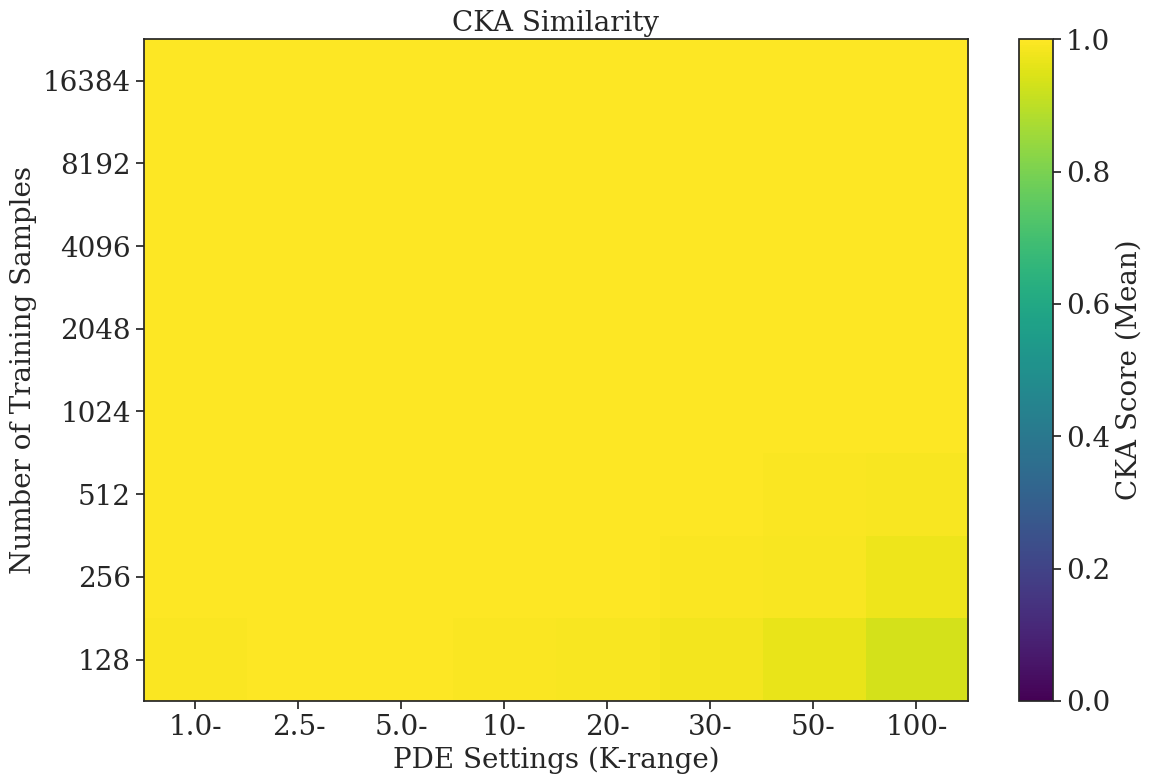

In [8]:
# Print statistics for linear kernel
print_cka_statistics(linear_stats, 'linear')

# Create heatmap for linear kernel
os.makedirs('./plots', exist_ok=True)
linear_im, linear_matrix = create_cka_heatmap(
    linear_stats, 
    'linear', 
    aggregation='mean',
    figsize=(12, 8),
    save_path='./plots/cka_linear_heatmap.png'
)


## RBF Kernel CKA Analysis


Loading RBF CKA statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]

RBF Kernel CKA Statistics:
  Total configurations: 64
  Missing data: 0
  Available scores: 640
  Mean CKA: 0.9727
  Std CKA: 0.0514
  Min CKA: 0.6907
  Max CKA: 1.0000
  Median CKA: 0.9983
  High similarity (>0.9): 575 (89.8%)
  Moderate similarity (0.7-0.9): 64 (10.0%)
  Low similarity (<0.7): 1 (0.2%)
Heatmap saved to: ./plots/cka_rbf_heatmap.png


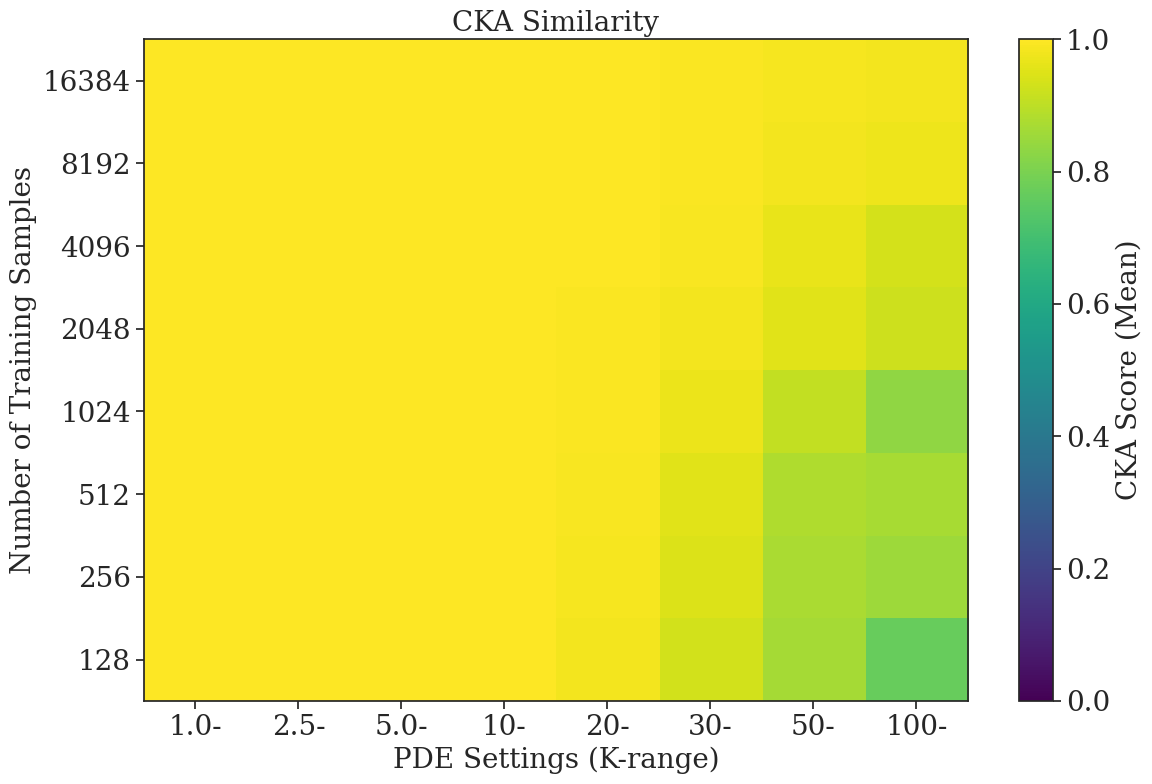

In [9]:
print("Loading RBF CKA statistics...")
rbf_stats = load_cka_statistics(kernel_type='rbf', aggregation='mean')

# Print statistics for RBF kernel
print_cka_statistics(rbf_stats, 'rbf')

# Create heatmap for RBF kernel
rbf_im, rbf_matrix = create_cka_heatmap(
    rbf_stats, 
    'rbf', 
    aggregation='mean',
    figsize=(12, 8),
    save_path='./plots/cka_rbf_heatmap.png'
)


Loading RBF CKA statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]

RBF Kernel CKA Statistics:
  Total configurations: 64
  Missing data: 0
  Available scores: 640
  Mean CKA: 0.9727
  Std CKA: 0.0514
  Min CKA: 0.6907
  Max CKA: 1.0000
  Median CKA: 0.9983
  High similarity (>0.9): 575 (89.8%)
  Moderate similarity (0.7-0.9): 64 (10.0%)
  Low similarity (<0.7): 1 (0.2%)
Heatmap saved to: ./plots/cka_rbf_heatmap.png


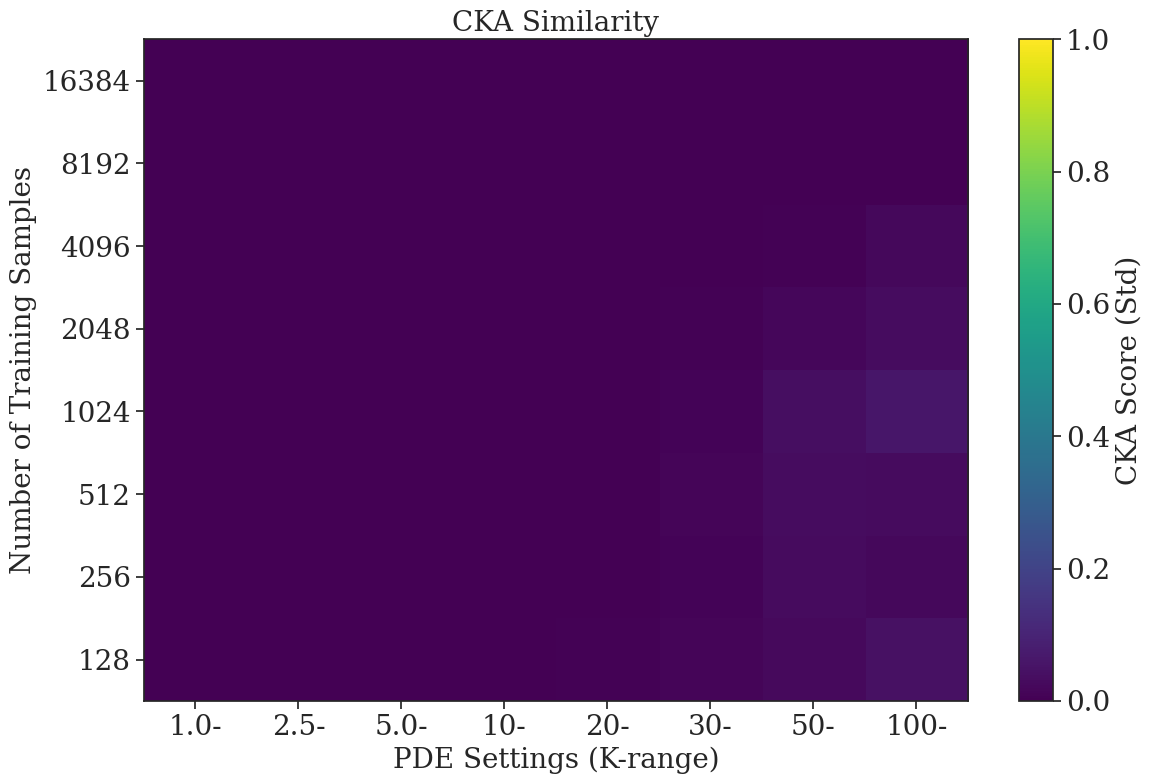

In [10]:
print("Loading RBF CKA statistics...")
rbf_stats = load_cka_statistics(kernel_type='rbf', aggregation='std')

# Print statistics for RBF kernel
print_cka_statistics(rbf_stats, 'rbf')

# Create heatmap for RBF kernel
rbf_im, rbf_matrix = create_cka_heatmap(
    rbf_stats, 
    'rbf', 
    aggregation='std',
    figsize=(12, 8),
    save_path='./plots/cka_rbf_heatmap.png'
)


## Comparative Analysis


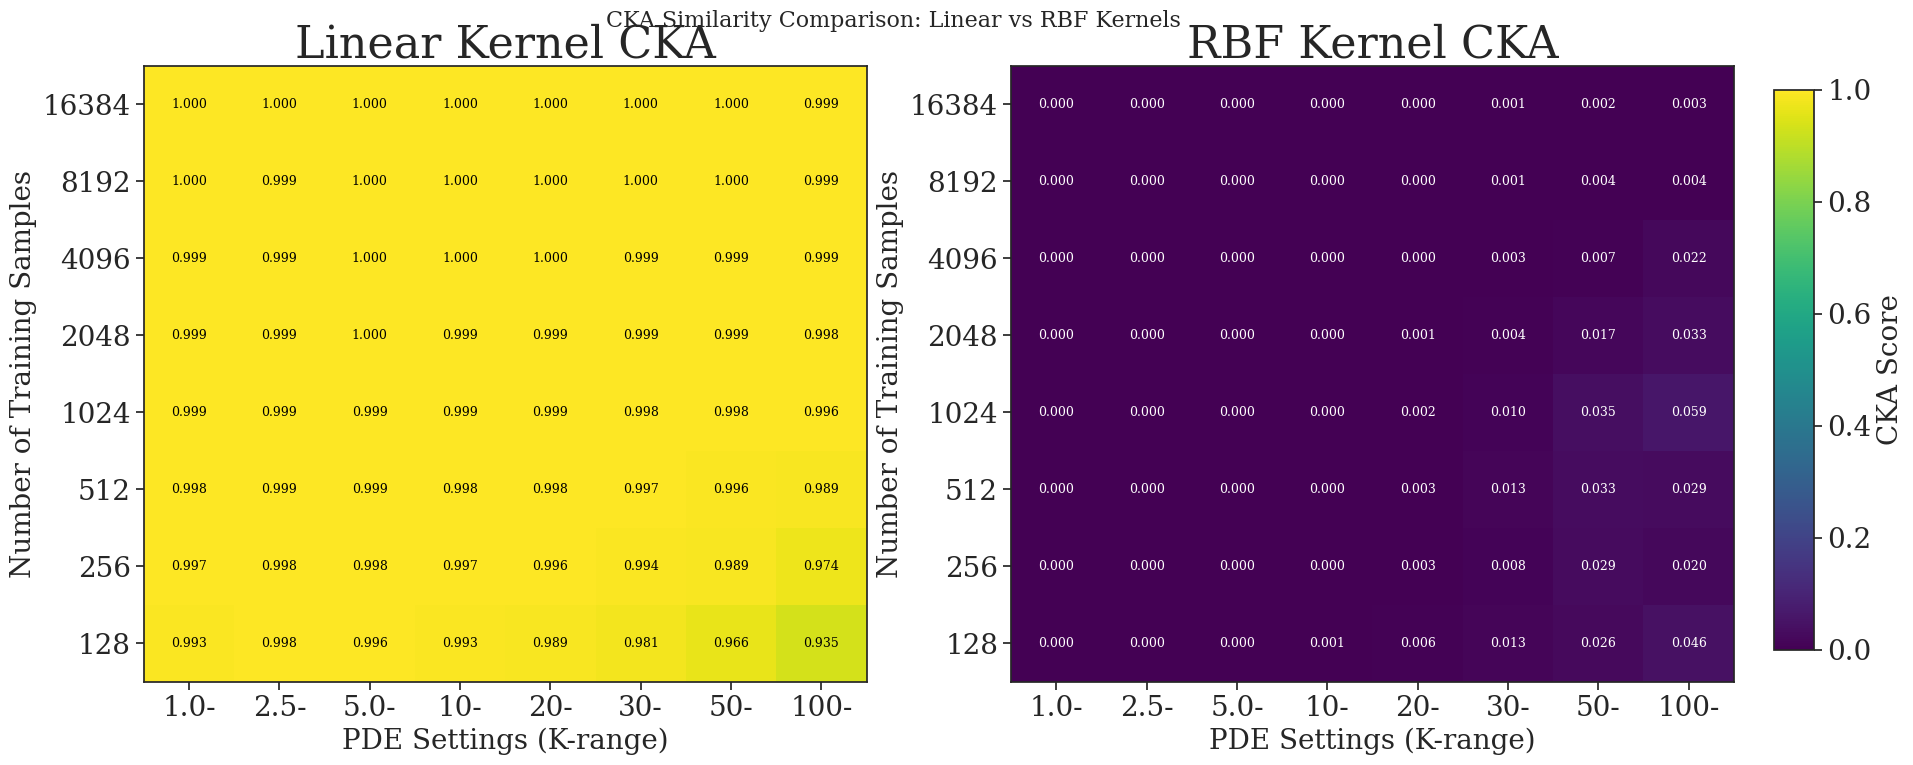

In [11]:
# Compare Linear vs RBF kernels side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Linear kernel heatmap
im1 = ax1.imshow(linear_matrix, aspect='auto', cmap='viridis', origin='lower', vmin=0, vmax=1)
ax1.set_xticks(np.arange(len(k_range_list)))
ax1.set_xticklabels(k_range_list, fontsize=medfont)
ax1.set_yticks(np.arange(len(sub_sampling_range)))
ax1.set_yticklabels(data_number_range, fontsize=medfont)
ax1.set_xlabel("PDE Settings (K-range)", fontsize=medfont)
ax1.set_ylabel("Number of Training Samples", fontsize=medfont)
ax1.set_title("Linear Kernel CKA", fontsize=largefont)

# Add text annotations for linear
for i in range(linear_matrix.shape[0]):
    for j in range(linear_matrix.shape[1]):
        if not np.isnan(linear_matrix[i, j]):
            text_color = 'white' if linear_matrix[i, j] < 0.5 else 'black'
            ax1.text(j, i, f'{linear_matrix[i, j]:.3f}', 
                    ha='center', va='center', color=text_color, fontsize=9)
        else:
            ax1.text(j, i, 'N/A', ha='center', va='center', color='red', fontsize=9)

# RBF kernel heatmap
im2 = ax2.imshow(rbf_matrix, aspect='auto', cmap='viridis', origin='lower', vmin=0, vmax=1)
ax2.set_xticks(np.arange(len(k_range_list)))
ax2.set_xticklabels(k_range_list, fontsize=medfont)
ax2.set_yticks(np.arange(len(sub_sampling_range)))
ax2.set_yticklabels(data_number_range, fontsize=medfont)
ax2.set_xlabel("PDE Settings (K-range)", fontsize=medfont)
ax2.set_ylabel("Number of Training Samples", fontsize=medfont)
ax2.set_title("RBF Kernel CKA", fontsize=largefont)

# Add text annotations for RBF
for i in range(rbf_matrix.shape[0]):
    for j in range(rbf_matrix.shape[1]):
        if not np.isnan(rbf_matrix[i, j]):
            text_color = 'white' if rbf_matrix[i, j] < 0.5 else 'black'
            ax2.text(j, i, f'{rbf_matrix[i, j]:.3f}', 
                    ha='center', va='center', color=text_color, fontsize=9)
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center', color='red', fontsize=9)

# Add shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("CKA Score", fontsize=medfont)

plt.suptitle("CKA Similarity Comparison: Linear vs RBF Kernels", fontsize=16, y=0.95)
plt.savefig('./plots/cka_comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Additional Analysis Options


In [12]:
# Optional: Load and visualize different aggregations (std, min, max)
# Uncomment and run the cells below for additional analysis

# # Standard deviation analysis
# print("Loading Standard Deviation Analysis...")
# linear_std_stats = load_cka_statistics(kernel_type='linear', aggregation='std')
# rbf_std_stats = load_cka_statistics(kernel_type='rbf', aggregation='std')

# # Create std heatmaps
# create_cka_heatmap(linear_std_stats, 'linear', aggregation='std', 
#                    figsize=(12, 8), save_path='./plots/cka_linear_std_heatmap.png')
# create_cka_heatmap(rbf_std_stats, 'rbf', aggregation='std', 
#                    figsize=(12, 8), save_path='./plots/cka_rbf_std_heatmap.png')

print("Analysis completed! Check the plots directory for saved heatmaps.")
print("\nTo run additional analysis:")
print("- Uncomment the cells above for standard deviation analysis")
print("- Modify kernel_type or aggregation parameters as needed")
print("- Add custom filtering or subset analysis")


Analysis completed! Check the plots directory for saved heatmaps.

To run additional analysis:
- Uncomment the cells above for standard deviation analysis
- Modify kernel_type or aggregation parameters as needed
- Add custom filtering or subset analysis


## Custom Analysis Functions


In [13]:
def analyze_specific_configuration(k_range, subsample, kernel_type='linear'):
    """Analyze CKA results for a specific configuration across all seed pairs."""
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    bsz = get_batch_size_for_subsample(subsample)
    lr = lr_range[0]
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    
    print(f"\nAnalyzing Configuration:")
    print(f"  PDE Setting: {pde_setting}")
    print(f"  Hyperparameters: {hyper_setting}")
    print(f"  Kernel: {kernel_type}")
    
    seed_pairs = list(combinations(seed_range, 2))
    results = []
    
    for seed_a, seed_b in seed_pairs:
        file_path = construct_cka_file_path(
            base_cka_dir, k_range, subsample, kernel_type, seed_a, seed_b
        )
        
        if os.path.exists(file_path):
            result = parse_cka_result_file(file_path)
            if result and 'cka_score' in result:
                results.append({
                    'seed_pair': f'{seed_a}_vs_{seed_b}',
                    'cka_score': result['cka_score'],
                    'cosine_similarity': result.get('mean_cosine_similarity', 'N/A'),
                    'num_samples': result.get('num_samples', 'N/A')
                })
        else:
            # Try reverse order
            file_path_alt = construct_cka_file_path(
                base_cka_dir, k_range, subsample, kernel_type, seed_b, seed_a
            )
            if os.path.exists(file_path_alt):
                result = parse_cka_result_file(file_path_alt)
                if result and 'cka_score' in result:
                    results.append({
                        'seed_pair': f'{seed_b}_vs_{seed_a}',
                        'cka_score': result['cka_score'],
                        'cosine_similarity': result.get('mean_cosine_similarity', 'N/A'),
                        'num_samples': result.get('num_samples', 'N/A')
                    })
    
    if results:
        df = pd.DataFrame(results)
        print(f"\nResults across {len(results)} seed pairs:")
        print(df.to_string(index=False))
        
        cka_scores = [r['cka_score'] for r in results]
        print(f"\nSummary Statistics:")
        print(f"  Mean CKA: {np.mean(cka_scores):.4f}")
        print(f"  Std CKA: {np.std(cka_scores):.4f}")
        print(f"  Min CKA: {np.min(cka_scores):.4f}")
        print(f"  Max CKA: {np.max(cka_scores):.4f}")
        
        return df
    else:
        print("No results found for this configuration.")
        return None

# Example usage - analyze a specific configuration
print("Example Analysis for k=[100.0, 200.0], subsample=4096, linear kernel:")
example_df = analyze_specific_configuration([100.0, 200.0], 4096, 'linear')


Example Analysis for k=[100.0, 200.0], subsample=4096, linear kernel:

Analyzing Configuration:
  PDE Setting: poisson_scale_k100.0_200.0_val1024_1M
  Hyperparameters: bsz8_lr0.001_subsample4096
  Kernel: linear

Results across 10 seed pairs:
   seed_pair  cka_score  cosine_similarity  num_samples
2022_vs_2021   0.773374           0.960565         1024
2023_vs_2021   0.938523           0.993047         1024
2024_vs_2021   0.603971           0.955602         1024
2025_vs_2021   0.914303           0.983576         1024
2023_vs_2022   0.858124           0.937425         1024
2024_vs_2022   0.883283           0.995094         1024
2025_vs_2022   0.897580           0.987705         1024
2024_vs_2023   0.685373           0.931167         1024
2025_vs_2023   0.927947           0.966053         1024
2025_vs_2024   0.757191           0.983863         1024

Summary Statistics:
  Mean CKA: 0.8240
  Std CKA: 0.1081
  Min CKA: 0.6040
  Max CKA: 0.9385
